# AG-HYPOPT · Trial 07

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Six trials recorded: trial_01 0.1907, trial_02 0.2075, trial_03 0.2472, trial_04 0.1987, trial_05 0.1863 (best), trial_06 0.2203 (first TPE pick). Configs and outcomes reinforce two facts: (i) mu_fit is near half of mu_true for every config (objective floor); (ii) the objective spread comes from the gamma term, dominated by the low-transmission (Trans05) estimate. The clearest single lesson is that very low gamma_anneal hurts (trial_03 anneal 0.064 -> 0.2472, worst) while strong anneal (~0.6-0.7) gave the best objective and gamma RMSE (trials 04/05). TPE is now well past warm-up (6/5) so its EI ranking is informative but its top picks drift toward low lr_mu/anneal. Context only.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_07'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 20    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (6/5 trials)
ID |     ei | params
 1 | 2.1982 | {"gamma_anneal": 0.6372457791449759, "lr_gamma": 0.910621887657185, "lr_mu": 26.838836134906547, "sigma_ref": 21.424568367655326}
 2 | 0.6393 | {"gamma_anneal": 0.3170236179137903, "lr_gamma": 0.42274048968061867, "lr_mu": 16.126907647066165, "sigma_ref": 15.41584421166593}
 3 | 2.8627 | {"gamma_anneal": 0.3345681283726807, "lr_gamma": 0.7713854108395254, "lr_mu": 9.005300846446113, "sigma_ref": 12.549605743537686}
 4 | 2.0596 | {"gamma_anneal": 0.3861666152035277, "lr_gamma": 0.8150357434958085, "lr_mu": 18.41922591418044, "sigma_ref": 7.4867129660243235}
 5 | 0.1176 | {"gamma_anneal": 0.5190240906613794, "lr_gamma": 0.49562904848176537, "lr_mu": 25.751193245043638, "sigma_ref": 10.351986091275709}
 6 | 3.5368 | {"gamma_anneal": 0.3907373097877963, "lr_gamma": 0.9646242024202777, "lr_mu": 5.0, "sigma_ref": 11.522786490400796}
 7 | 2.6590 | {"gamma_anneal": 0.599367352096285, "lr_gamma": 0.7766320231301568, "lr_mu": 20.611

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

TPE (6/5) ranks candidates by expected improvement. The two highest-EI picks, candidate 6 (EI 3.54) and candidate 3 (EI 2.86), sit in regions with weak gamma_anneal (0.39 and 0.34) and an lr_mu pushed to the lower boundary (5.0 and 9.0) -- exactly the low-anneal regime that produced the campaign's worst trial (trial_03, anneal 0.064). The next-highest-EI candidate that is consistent with the campaign's clearest finding (strong anneal protects the low-transmission gamma estimate) is candidate 7 (EI 2.66): gamma_anneal 0.599 (close to the best trial's 0.604), lr_gamma 0.777, lr_mu 20.61, sigma_ref 21.33 (a region like trial_01's, which scored 0.1907). Among the high-anneal candidates it has the highest EI. I choose candidate 7.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 7               # highest-EI pick consistent with the strong-anneal lesson


chosen: {'gamma_anneal': 0.599367352096285, 'lr_gamma': 0.7766320231301568, 'lr_mu': 20.611569799548583, 'sigma_ref': 21.326762076381513}
Running  1nW Trans05 ... 

μ 9.39 -> 4.73 | γ 8.5 -> 3.97 | NLL 1.29


Running  1nW Trans20 ... 

μ 17.32 -> 8.64 | γ 8.5 -> 5.45 | NLL 2.85


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 49.98 | γ 14.1 -> 13.26 | NLL 2.98


Running 3nW Trans100 ... 

μ 175.71 -> 84.38 | γ 14.1 -> 13.50 | NLL 3.03



Total: 2.4 min


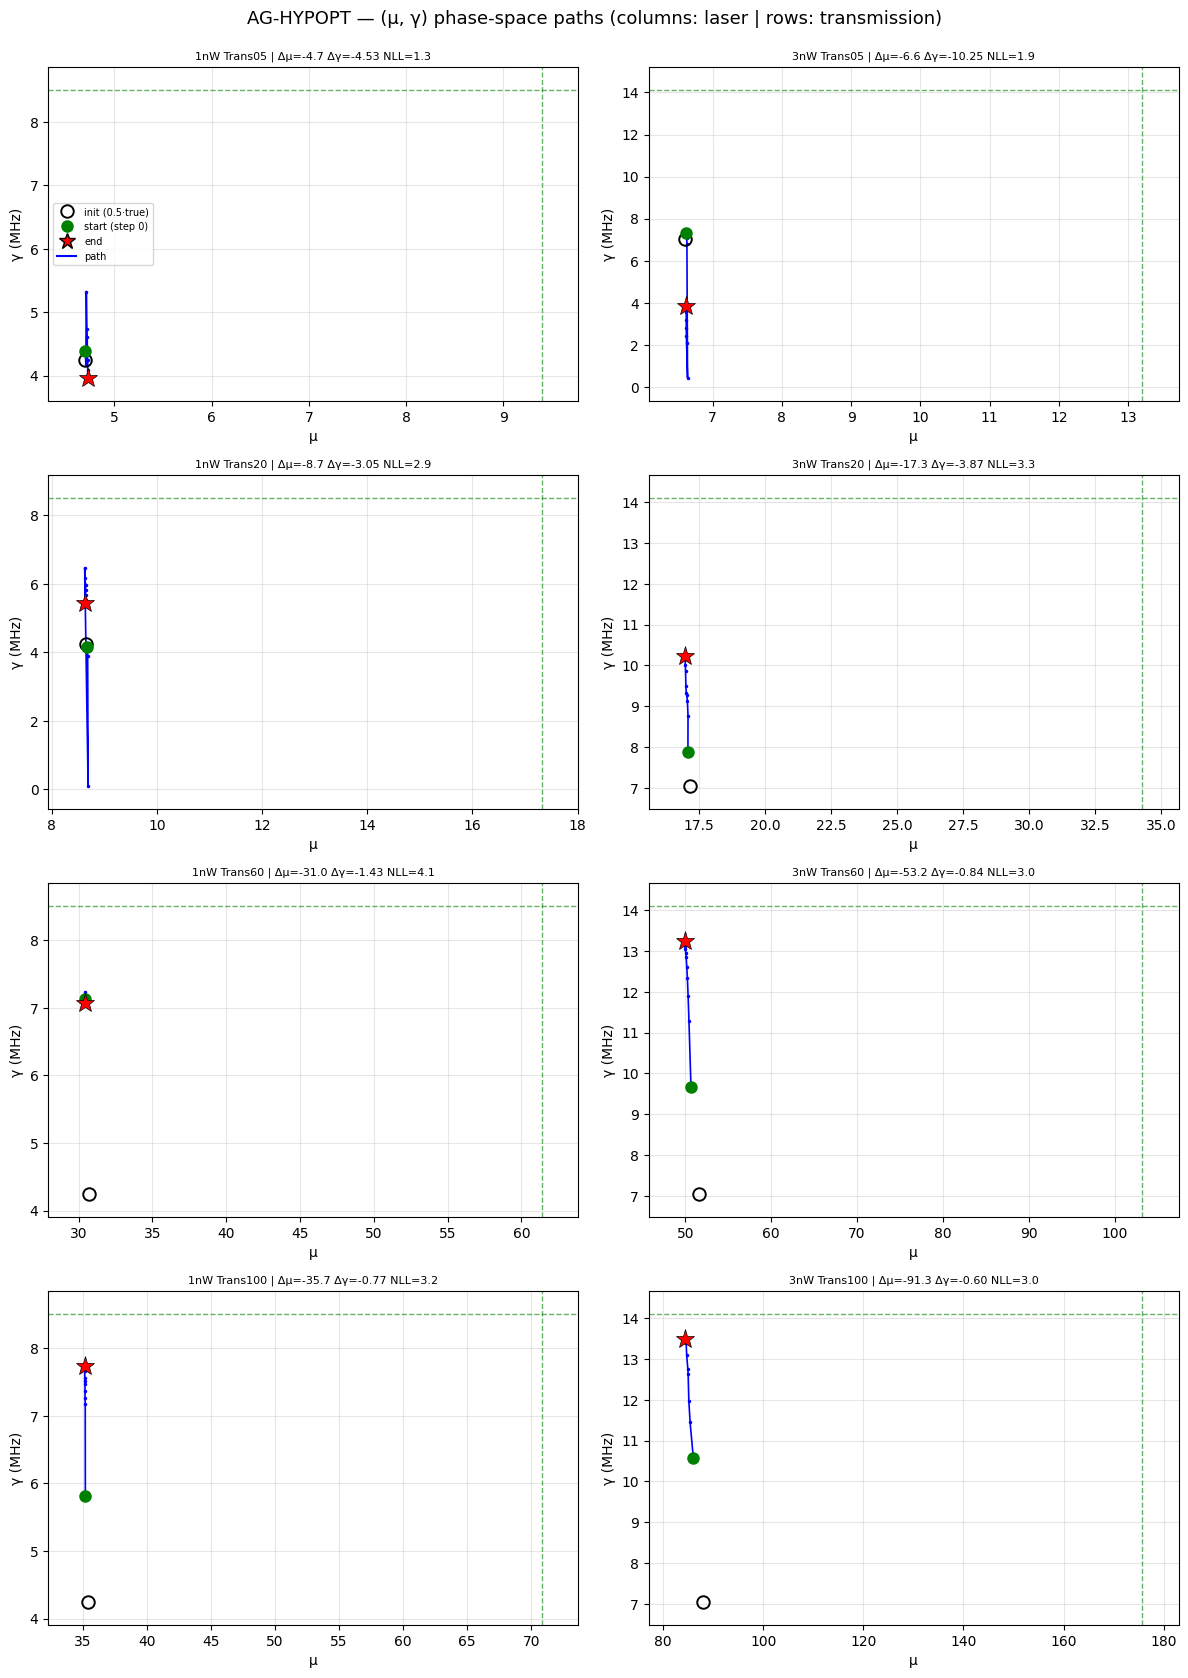

trial finished in 2.4 min
objective = 0.1940 ± 0.0356
exp           μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05     9.39    4.73   -49.7 |     8.50    3.97   -53.3
1nW Trans20    17.32    8.64   -50.1 |     8.50    5.45   -35.8
1nW Trans60    61.37   30.42   -50.4 |     8.50    7.07   -16.9
1nW Trans100   70.82   35.14   -50.4 |     8.50    7.73    -9.1
3nW Trans05    13.20    6.62   -49.9 |    14.10    3.85   -72.7
3nW Trans20    34.28   16.97   -50.5 |    14.10   10.23   -27.4
3nW Trans60   103.20   49.98   -51.6 |    14.10   13.26    -6.0
3nW Trans100  175.71   84.38   -52.0 |    14.10   13.50    -4.2

μ: RMSE 41.599 (rel 50.6%, bias -31.052) | γ: RMSE 4.382 (rel 36.4%, bias -3.167)


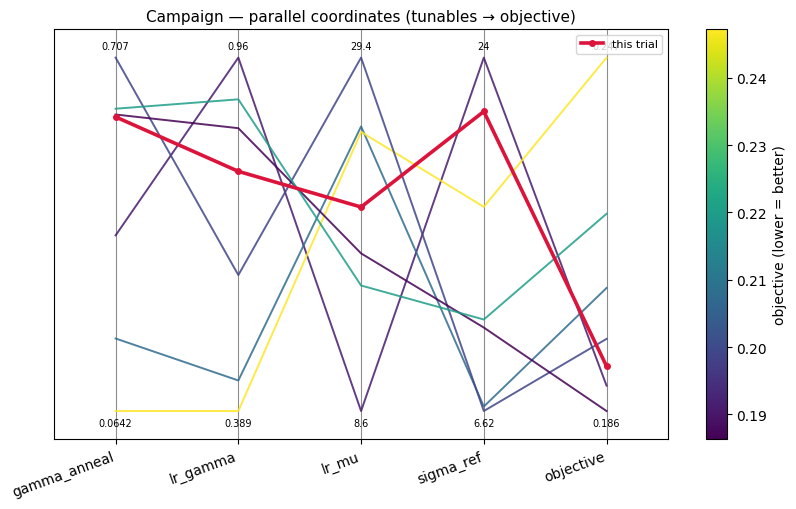

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 07, second TPE-driven trial; chosen as the highest-EI candidate consistent with the strong-anneal lesson: sigma_ref 21.33, lr_mu 20.61, lr_gamma 0.777, gamma_anneal 0.599. Result: objective 0.1940 +/- 0.0356, the third-best of the campaign (behind trial_05 0.1863 and trial_01 0.1907), runtime 2.4 min. mu_fit is again near half of mu_true and very uniform (Delta-mu% -49.7 to -52.0), mu RMSE 41.60 (relative 50.6%, bias -31.1) -- the cleanest mu attractor yet and the best mu RMSE so far. gamma_fit is strong at high transmission (3 nW Trans60/100: -6.0/-4.2%; 1 nW Trans100: -9.1%) but still degrades at low transmission (1 nW Trans05 -53.3%, 3 nW Trans05 -72.7%; 1 nW Trans20 -35.8%), gamma RMSE 4.38 (relative 36.4%). The strong anneal partially helped (mid/high T good) but did not rescue the Trans05 gamma.

**Summary:** Trial 07 (sigma_ref 21.33, lr_mu 20.61, lr_gamma 0.777, gamma_anneal 0.599) -> objective 0.1940 +/- 0.0356, third best so far and the best mu RMSE (50.6% rel); gamma good at high T, still poor at Trans05.
**Key insight:** This config gives the tightest, most uniform half-truth mu attractor of the campaign, but the Trans05 gamma collapse persists even with anneal ~0.6 -- confirming the loss is set jointly by an invariant mu gap and an unstable low-transmission gamma estimate.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
No new structural notes; the real-data attractor note from trial_01 still stands.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 07 (sigma_ref 21.33, lr_mu 20.61, lr_gamma 0.777, gamma_anneal 0.599): objective 0.1940 +/- 0.0356, third best so far and best mu RMSE (50.6% rel); gamma good at high T, still poor at Trans05'
KEY_INSIGHT = 'This config gives the tightest half-truth mu attractor yet, but the Trans05 gamma collapse persists at anneal ~0.6 -- the loss is jointly set by an invariant mu gap and an unstable low-transmission gamma estimate.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_07 | current best: trial_05


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_08.ipynb. Open it and follow its cells from the top.
